Initial Wide FOV results to show the evolution of the flow field.

Initially showing the contours of the flow same as with the narrow field, then doing some tracking, then on to the Inerital wave identification and kinetic energy analysis.

Boilerplate code

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import h5py
import matplotlib.colors as colors
import matplotlib.cm

#####Import Ollie Tools
dirPath = "C:/Coding"
sys.path.insert(0, dirPath)
import OllieTools as oj
print(dirPath)


####Import Ollie Tools MAC
# dirPath = "/Users/olliejackson/Coding"
# sys.path.insert(0, dirPath)
# import OllieTools as oj
# print(dirPath)

oj.thesis_plot_settings()

C:/Coding/Code
C:/Coding
Thesis plot settings applied


In [10]:

h5file = h5py.File('E:/H5/WideFOV.h5', 'r')
vels = h5file['Wide']['U200']['L100']['RPM12']

u = vels[:,:,:,0]
v = vels[:,:,:,1]
h5file.close()

u, v = oj.scaleVel(u, v, 60)
u, v = u*25, v*25
r_nd, z_nd = oj.NDUnitsForPlotsWide(u.shape[1], u.shape[2])

Time = oj.frames_to_seconds(u, v, 60)
vort, vort_gauss = oj.calculate_vorticity(u, v)

Contour of flow field plots
* u
* v
* $\omega$

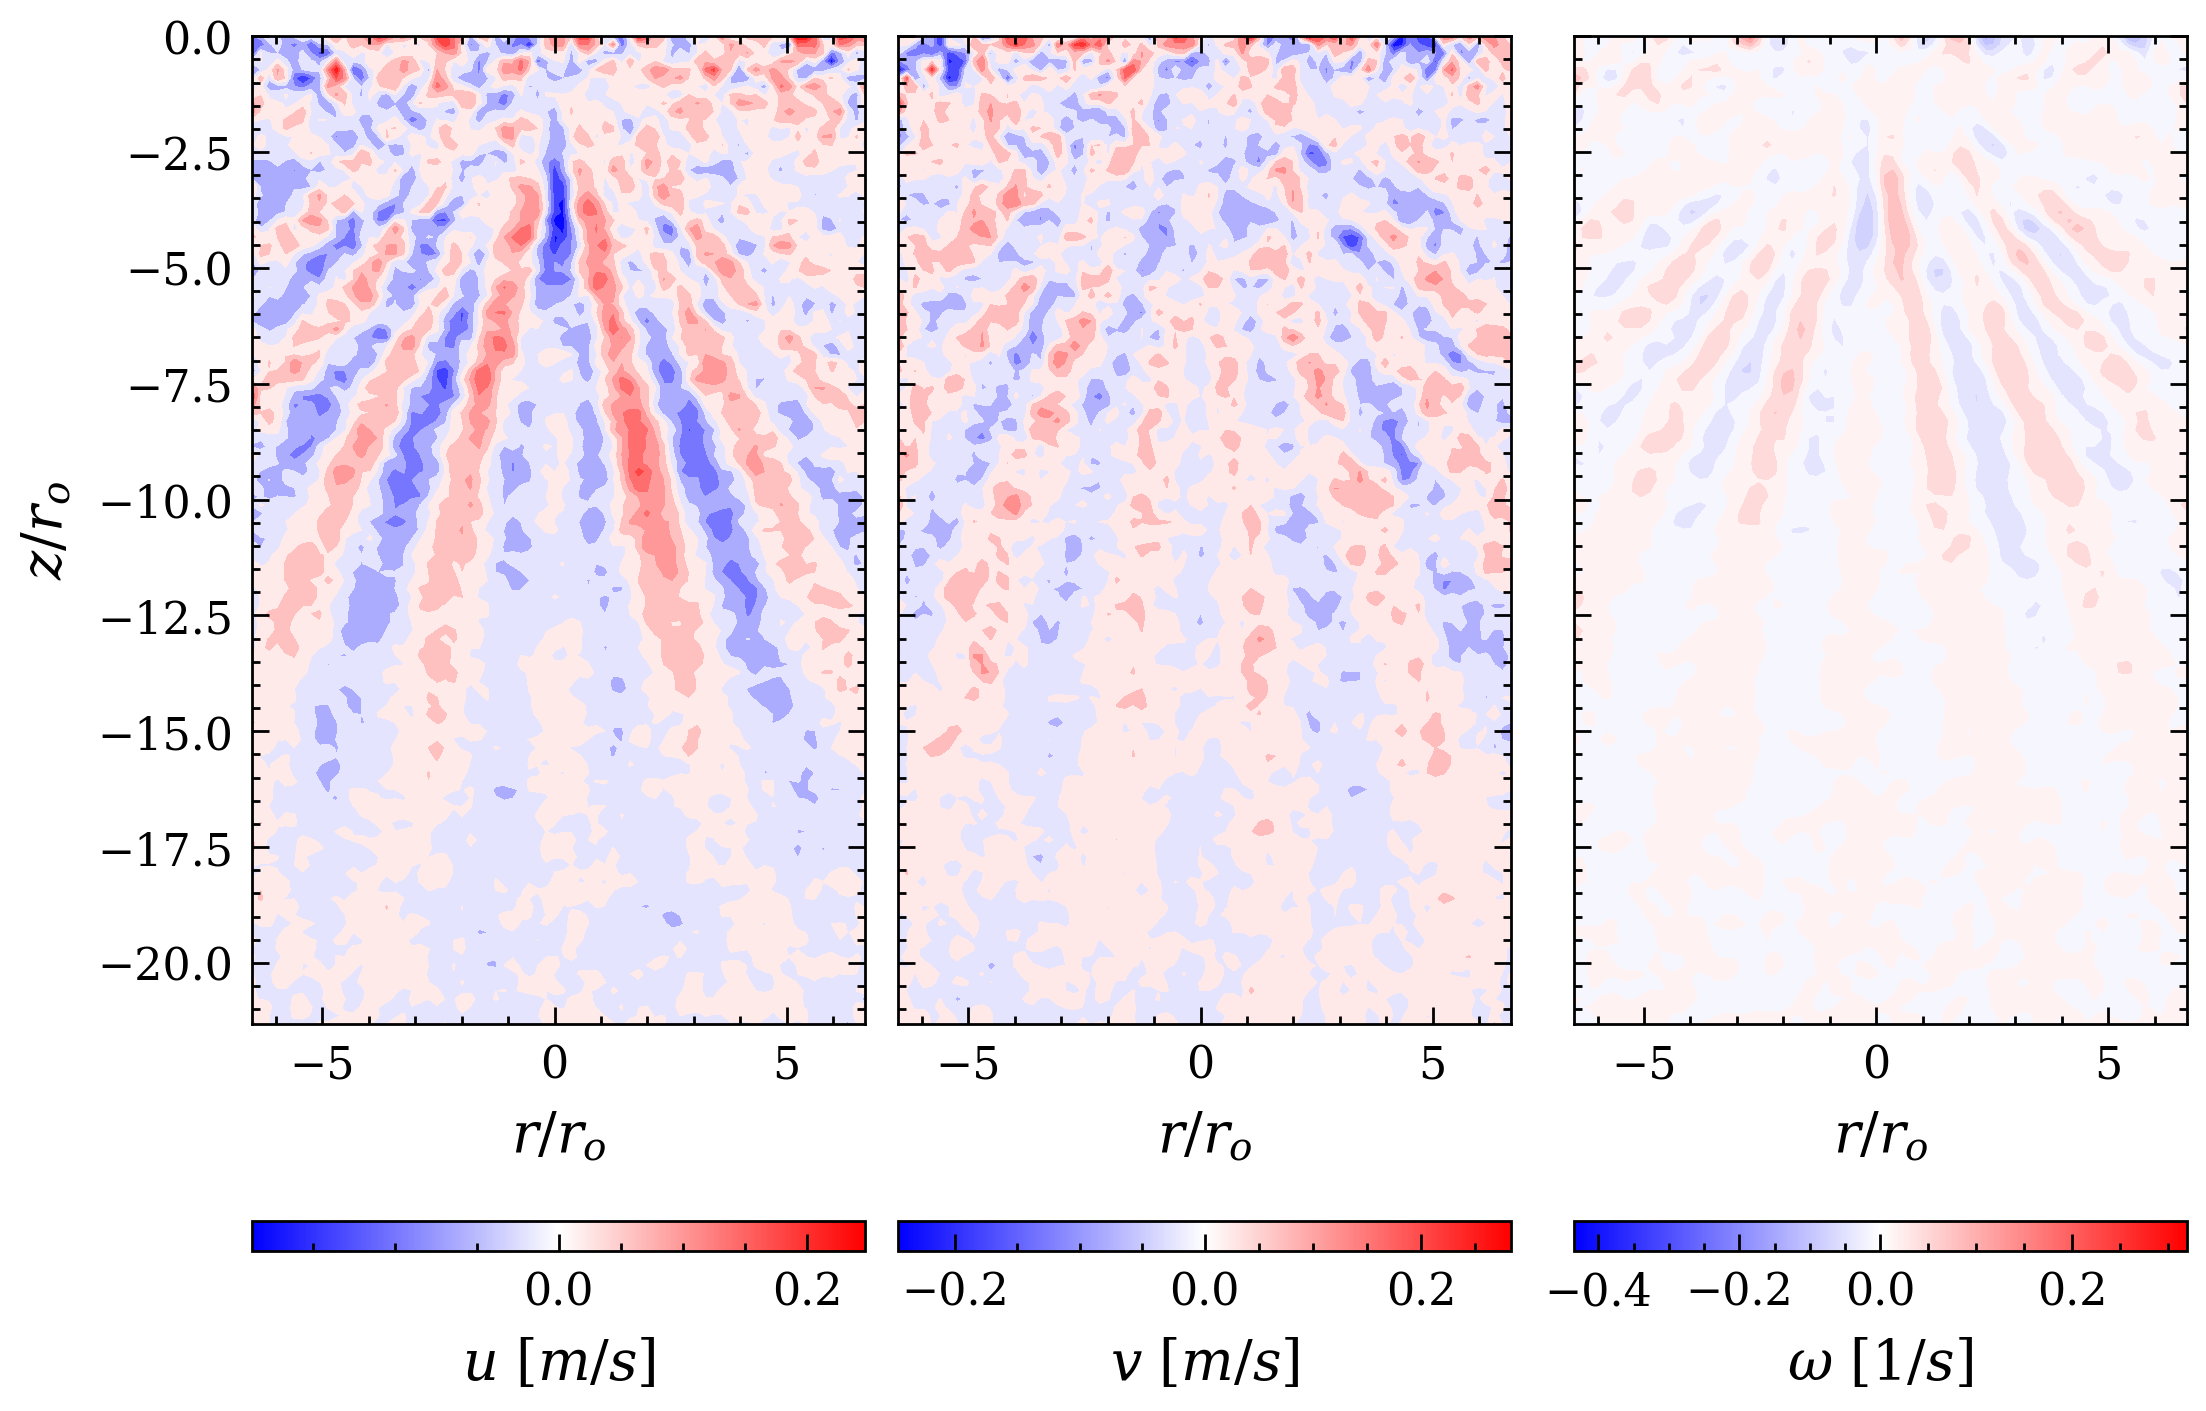

In [11]:
# norm = colors.TwoSlopeNorm(vmin=np.min(u[frame, :, :]), vcenter=0, vmax=np.max(u[frame, :, :]))
# fig, ax = plt.subplots(1, 1)
# ax.contourf(r_nd, -z_nd, np.rot90(u[frame, :, :], 3), norm=norm, cmap='bwr', levels=10)
# fig.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap='bwr'), ax=ax, label=r'$u$' )
# plt.show()
frame = 750

unorm = colors.TwoSlopeNorm(vmin=np.min(u[frame, :, :]), vcenter=0, vmax=np.max(u[frame, :, :]))
vnorm = colors.TwoSlopeNorm(vmin=np.min(v[frame, :, :]), vcenter=0, vmax=np.max(v[frame, :, :]))
onorm = colors.TwoSlopeNorm(vmin=np.min(vort[frame, :, :]), vcenter=0, vmax=np.max(vort[frame, :, :]))


f1, axs = plt.subplots(1, 3, figsize=(5.5, 3.5), layout='constrained')
axs[0].contourf(r_nd, -z_nd, np.rot90(u[frame, :, :], 3), norm=unorm, cmap='bwr', levels=10)
axs[0].set_xlabel(r"$r/r_{o}$")
axs[0].set_ylabel(r"$z/r_{o}$")
f1.colorbar(matplotlib.cm.ScalarMappable(norm=unorm, cmap='bwr'), ax=axs[0], label=r'$u ~[m/s]$', location='bottom')
axs[1].contourf(r_nd, -z_nd, np.rot90(v[frame, :, :], 3), norm=vnorm, cmap='bwr', levels=10)
axs[1].set_xlabel(r"$r/r_{o}$")
axs[1].set_yticklabels([])
f1.colorbar(matplotlib.cm.ScalarMappable(norm=vnorm, cmap='bwr'), ax=axs[1], label=r'$v ~[m/s]$', location='bottom')
axs[2].contourf(r_nd, -z_nd, np.rot90(vort_gauss[frame, :, :], 3), norm=onorm, cmap='bwr', levels=10)
axs[2].set_xlabel(r"$r/r_{o}$")
axs[2].set_yticklabels([])
f1.colorbar(matplotlib.cm.ScalarMappable(norm=onorm, cmap='bwr'), ax=axs[2], label=r'$\omega ~[1/s]$', location='bottom')




3 $\times$ 3 plot showing the difference in the field 

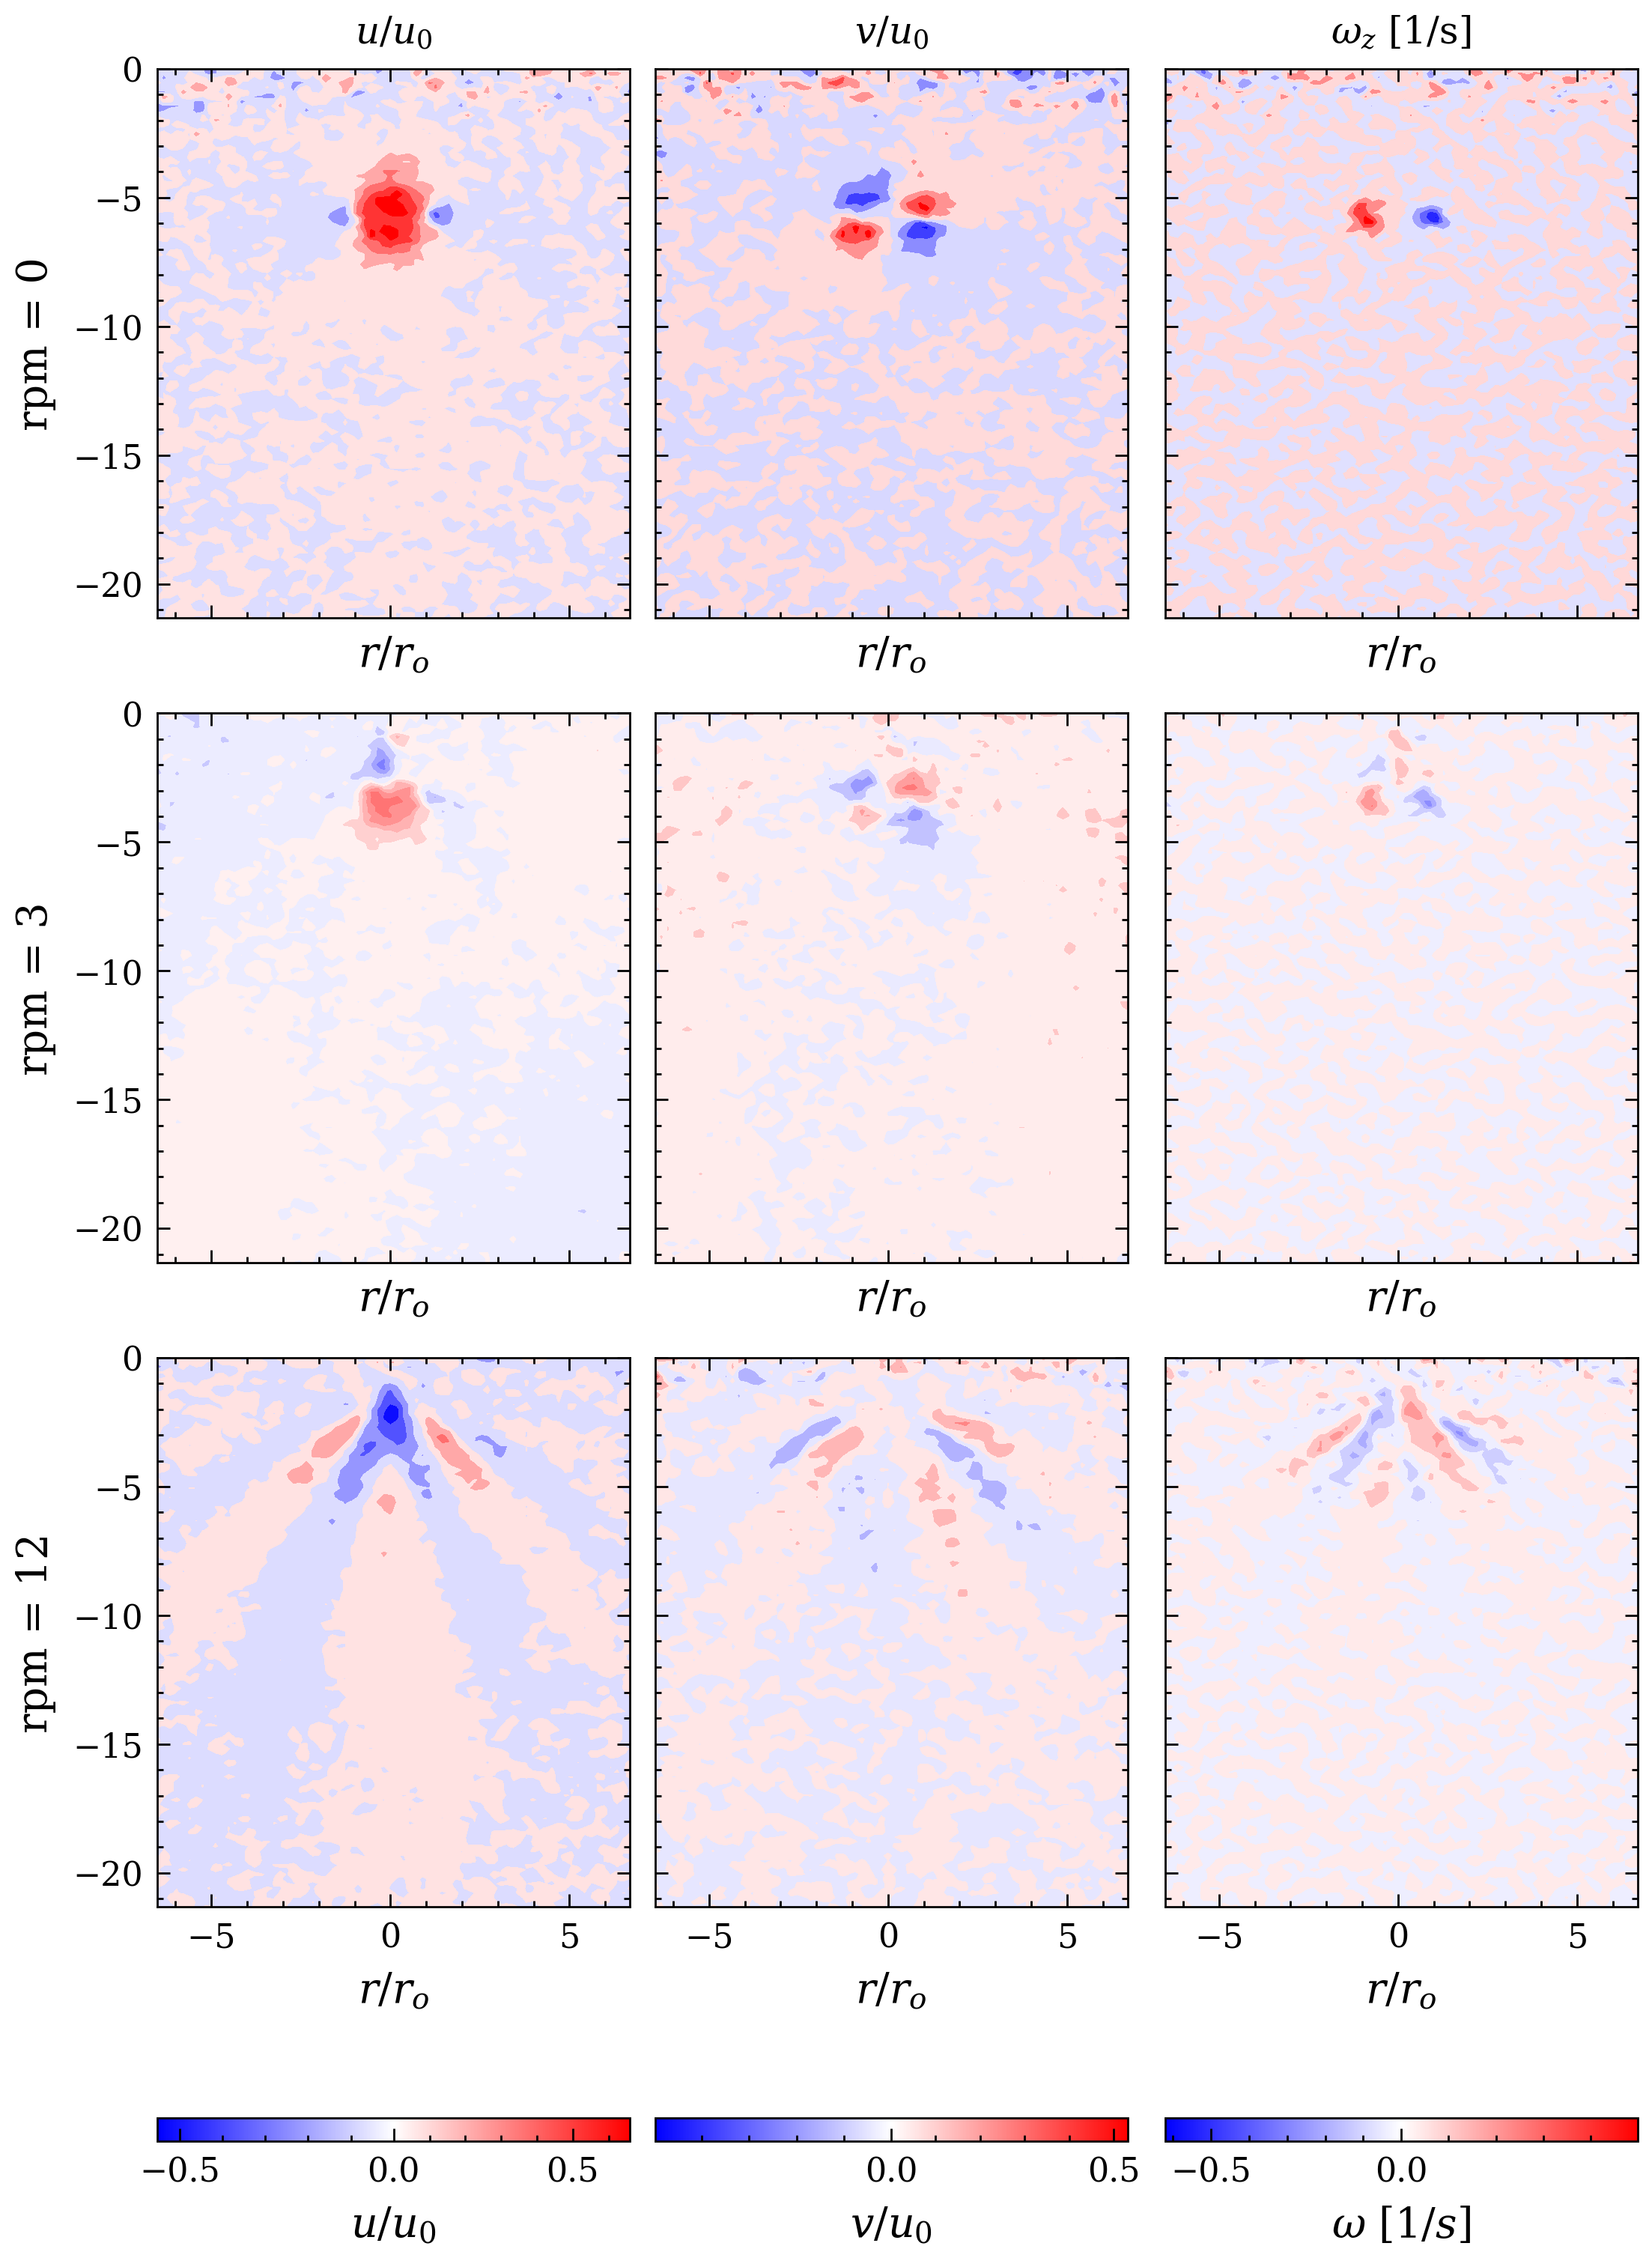

In [6]:
h5file = h5py.File('E:/H5/WideFOV.h5', 'r')
index = 0
rpms = [0, 3, 12]
Eks = [0.0000102, 0.0000051, 0.0000034]

# umin = np.min(u[frame,:,:])
# umax = np.max(u[frame,:,:])
# unorm = colors.TwoSlopeNorm(vmin=umin, vcenter=0, vmax=umax)

# vmin = np.min(v[frame,:,:])
# vmax = np.max(v[frame,:,:])
# vnorm = colors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

# omin = np.min(vort[frame,:,:])
# omax = np.max(vort[frame,:,:])
# onorm = colors.TwoSlopeNorm(vmin=omin, vcenter=0, vmax=omax)

# f2, ax = plt.subplots(3, 3, sharex=True, sharey=True, figsize=(5.5, 7.5), dpi = 400)
# for i in range(3):
#     ax[0, 0].set_title(r'$u/u_{0}$', fontsize=9)
#     ax[0, 1].set_title(r'$v/u_{0}$', fontsize=9)
#     ax[0, 2].set_title(r'$\omega_{z}$ [1/s]', fontsize=9)

#     vels = h5file['Wide']['U200']['L100'][f'RPM{str(rpms[i])}']
#     # vels = h5file['Wide']['U200']['L100'][f'RPM0']
#     u = vels[:,:,:,0]
#     v = vels[:,:,:,1]
#     u, v = oj.scaleVel(u, v, 60) #make suer to change this for the wide fov data
#     u, v = u/0.2, v/0.2
#     vort, vortGauss = oj.calculate_vorticity(u, v)

#     ax[i, 0].contourf(r_nd, -z_nd, np.rot90(u   [frame,:,:],3), cmap = 'bwr', )
#     ax[i, 0].set_xlabel(r"$r/r_{o}$")
#     ax[i, 0].set_ylabel(rf"$Ek =$ {Eks[index]}")
#     ax[i, 1].contourf(r_nd, -z_nd, np.rot90(v   [frame,:,:],3), cmap = 'bwr', )
#     ax[i, 1].set_xlabel(r"$r/r_{o}$")
#     ax[i, 2].contourf(r_nd, -z_nd, np.rot90(vort[frame,:,:],3), cmap = 'bwr', )
#     ax[i, 2].set_xlabel(r"$r/r_{o}$")

# f2.colorbar(matplotlib.cm.ScalarMappable(norm=unorm, cmap='bwr'), ax=ax[:,0], label=r'$u/u_{0}$', location='bottom')
# f2.colorbar(matplotlib.cm.ScalarMappable(norm=vnorm, cmap='bwr'), ax=ax[:,1], label=r'$v/u_{0}$', location='bottom')
# f2.colorbar(matplotlib.cm.ScalarMappable(norm=onorm, cmap='bwr'), ax=ax[:,2], label=r'$\omega ~[1/s]$', location='bottom')

# plt.show()
vels = h5file['Wide']['U200']['L100'][f'RPM0']
u = vels[:,:,:,0]
v = vels[:,:,:,1]

u = np.zeros((u.shape[0], u.shape[1], u.shape[2],3))
v = np.zeros((u.shape[0], u.shape[1], u.shape[2],3))
vort = np.zeros((u.shape[0], u.shape[1], u.shape[2], 3))
vortGauss = np.zeros((u.shape[0], u.shape[1], u.shape[2], 3))


for i in range(3):
    vels = h5file['Wide']['U200']['L100'][f'RPM{str(rpms[i])}']
    # vels = h5file['Wide']['U200']['L100'][f'RPM0']
    u[:,:,:,i] = vels[:,:,:,0]
    v[:,:,:,i] = vels[:,:,:,1]
    u[:,:,:,i], v[:,:,:,i] = oj.scaleVel(u[:,:,:,i], v[:,:,:,i], 60) #make sure to change this for the wide fov data
    u[:,:,:,i], v[:,:,:,i] = u[:,:,:,i]*25, v[:,:,:,i]*25
    vort[:,:,:,i], vortGauss[:,:,:,i] = oj.calculate_vorticity(u[:,:,:,i], v[:,:,:,i])


umin = np.min(u[frame,:,:,:])
umax = np.max(u[frame,:,:,:])
unorm = colors.TwoSlopeNorm(vmin=umin, vcenter=0, vmax=umax)

vmin = np.min(v[frame,:,:,:])
vmax = np.max(v[frame,:,:,:])
vnorm = colors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

omin = np.min(vort[frame,:,:,:])
omax = np.max(vort[frame,:,:,:])
onorm = colors.TwoSlopeNorm(vmin=omin, vcenter=0, vmax=omax)


fig, ax = plt.subplots(3, 3, sharex=True, sharey=True, figsize=(5.5, 7.5), dpi = 400)
for i in range(3):
    ax[0, 0].set_title(r'$u/u_{0}$', fontsize=9)
    ax[0, 1].set_title(r'$v/u_{0}$', fontsize=9)
    ax[0, 2].set_title(r'$\omega_{z}$ [1/s]', fontsize=9)

    ax[i, 0].contourf(r_nd, -z_nd, np.rot90(u   [frame,:,:,i],3), cmap = 'bwr', norm = unorm)
    ax[i, 0].set_xlabel(r"$r/r_{o}$")
    ax[i, 0].set_ylabel(rf"rpm = {rpms[i]}")
    ax[i, 1].contourf(r_nd, -z_nd, np.rot90(v   [frame,:,:,i],3), cmap = 'bwr', norm = vnorm)
    ax[i, 1].set_xlabel(r"$r/r_{o}$")
    ax[i, 2].contourf(r_nd, -z_nd, np.rot90(vort[frame,:,:,i],3), cmap = 'bwr', norm = onorm)
    ax[i, 2].set_xlabel(r"$r/r_{o}$")

fig.colorbar(matplotlib.cm.ScalarMappable(norm=unorm, cmap='bwr'), ax=ax[:,0], label=r'$u/u_{0}$', location='bottom')
fig.colorbar(matplotlib.cm.ScalarMappable(norm=vnorm, cmap='bwr'), ax=ax[:,1], label=r'$v/u_{0}$', location='bottom')
fig.colorbar(matplotlib.cm.ScalarMappable(norm=onorm, cmap='bwr'), ax=ax[:,2], label=r'$\omega ~[1/s]$', location='bottom')